### Subargument 5: The relationship between study time and academic performance may differ by gender

In [3]:
# Import
import pandas as pd
import numpy as np
import plotly.graph_objs as go
import plotly.express as px

from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [4]:
# Read in
df = pd.read_csv("student_habits_performance.csv")



# Remove duplicates


df = df.drop_duplicates()



# Handle missing values


    # Fill numerical missing values with median
numeric_cols = df.select_dtypes(include=np.number).columns
    
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

    # Fill categorical missing values with mode
categorical_cols = df.select_dtypes(include='object').columns
    
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# Filter unwanted outliers
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)


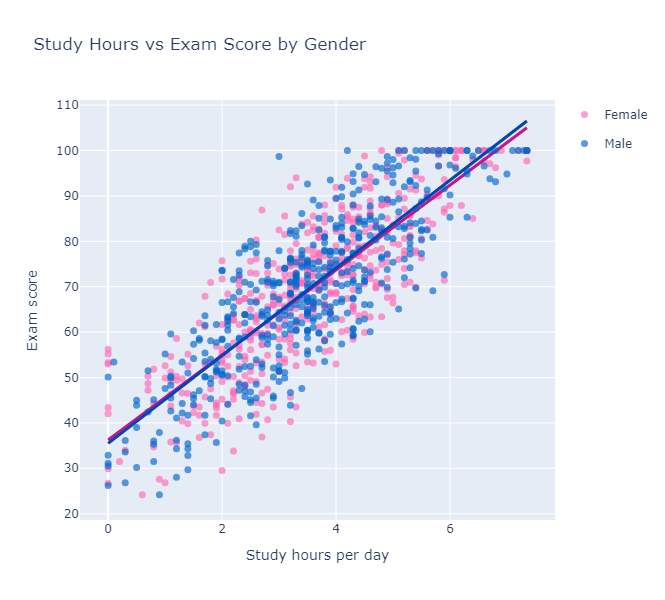

In [5]:
import plotly.graph_objects as go
import numpy as np

# Split data
female_df = df[df['gender'] == 'Female']
male_df = df[df['gender'] == 'Male']

# Helper function for linear regression line
def make_trendline(x, y):
    coeffs = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = coeffs[0] * x_line + coeffs[1]
    return x_line, y_line

# Trendlines
x_female, y_female = make_trendline(female_df['study_hours_per_day'], female_df['exam_score'])
x_male, y_male = make_trendline(male_df['study_hours_per_day'], male_df['exam_score'])

# Female scatter
female_scatter = go.Scatter(
    x=female_df['study_hours_per_day'],
    y=female_df['exam_score'],
    mode='markers',
    name='Female',
    marker=dict(
        color='rgb(255,105,180)',
        size=7,
        opacity=0.65
    ),
    legendgroup='female'
)

# Female trend line
female_line = go.Scatter(
    x=x_female,
    y=y_female,
    mode='lines',
    name='Female trend',
    line=dict(color='rgb(199,21,133)', width=3),
    legendgroup='female',
    showlegend=False
)

# Male scatter
male_scatter = go.Scatter(
    x=male_df['study_hours_per_day'],
    y=male_df['exam_score'],
    mode='markers',
    name='Male',
    marker=dict(
        color='rgb(0,102,204)',
        size=7,
        opacity=0.65
    ),
    legendgroup='male'
)

# Male trend line
male_line = go.Scatter(
    x=x_male,
    y=y_male,
    mode='lines',
    name='Male trend',
    line=dict(color='rgb(0,70,180)', width=3),
    legendgroup='male',
    showlegend=False
)

# Layout
layout = go.Layout(
    title='Study Hours vs Exam Score by Gender',
    xaxis=dict(title='Study hours per day'),
    yaxis=dict(title='Exam score'),
    height=600
)

# Figure
fig = go.Figure(
    data=[female_scatter, female_line, male_scatter, male_line],
    layout=layout
)

fig.show()

#### Interpretation

- Same pattern → Gender does not moderate relationship between exam score and study hours
- Dedicating time to studying brings higher score is a universal patterns across gender → add nuance to subargument 1

#### Design justification

An interactive scatterplot with correlational lines was adopted to examine whether the relationship between exam score and study time differs by gender. The interactive feature (click to display/hide plot of female/male) and the colors chosen help to emphasize the contrast between female and male data. As these data are presented in the same graph, readers can easily see the lines of female and male overlap largely, thus able to come to a conclusion. 
